In [33]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 1. Cargar el dataset
df_fighters = pd.read_csv('ufc_fighters_final.csv')

# 2. Limpieza básica
cols_to_numeric = [
    'Wins',
    'Losses',
    'Draws',
    'SLpM',
    'SApM',
    'TD_Avg',
    'Sub_Avg'
]

for col in cols_to_numeric:
    df_fighters[col] = pd.to_numeric(df_fighters[col], errors='coerce')

df_clean = df_fighters.dropna(subset=cols_to_numeric).copy()

# 3. Filtrar peleadores con mínimo 5 peleas
df_clean['Total_Fights'] = (
    df_clean['Wins'] +
    df_clean['Losses'] +
    df_clean['Draws']
)

df_ranking = df_clean[df_clean['Total_Fights'] >= 5].copy()

# 4. Variables compuestas
df_ranking['Net_Damage'] = (
    df_ranking['SLpM'] - df_ranking['SApM']
)

df_ranking['Finish_Rate'] = (
    df_ranking['Wins'] / df_ranking['Total_Fights']
)

print(f"Peleadores elegibles para el ranking P4P: {len(df_ranking)}")

print(df_fighters.columns.tolist())

Peleadores elegibles para el ranking P4P: 4125
['Fighter_Name', 'Height', 'Weight', 'Reach', 'Stance', 'DOB', 'Wins', 'Losses', 'Draws', 'SLpM', 'Str_Acc', 'SApM', 'Str_Def', 'TD_Avg', 'TD_Acc', 'TD_Def', 'Sub_Avg', 'Fighter_URL']


In [34]:
# 1. Seleccionar las columnas que vamos a evaluar
# Usamos Net_Damage (Daño), TD_Avg (Control) y Finish_Rate (Finalización)

features_to_scale = ['Net_Damage', 'TD_Avg', 'Finish_Rate']

# 2. Instanciar el escalador
scaler = MinMaxScaler(feature_range=(0, 100))

# 3. Aplicar transformación
scaled_features = scaler.fit_transform(df_ranking[features_to_scale])

# 4. Guardar resultados
df_ranking['Damage_Norm'] = scaled_features[:, 0]
df_ranking['Control_Norm'] = scaled_features[:, 1]
df_ranking['Finish_Norm'] = scaled_features[:, 2]

print("Visualización rápida de los datos normalizados (escala 0 a 100):")

display(
    df_ranking[
        ['Fighter_Name', 'Damage_Norm', 'Control_Norm', 'Finish_Norm']
    ].head()
)

Visualización rápida de los datos normalizados (escala 0 a 100):


,Fighter_Name,Damage_Norm,Control_Norm,Finish_Norm
0,Tom Aaron,61.538462,0.000000,62.500000
1,Danny Abbadi,59.384615,0.000000,40.000000
2,Nariman Abbasov,56.403846,0.000000,87.500000
3,Darion Abbey,50.730769,0.000000,64.285714
4,David Abbott,57.307692,4.437993,40.000000


In [35]:
# 1. Definir los pesos ponderados base
W_DAMAGE = 0.40
W_CONTROL = 0.30
W_FINISH = 0.30

# Calcular el Índice de Dominancia Base (Histórico)
df_ranking['Dominance_Base_Score'] = (
    (df_ranking['Damage_Norm'] * W_DAMAGE) + 
    (df_ranking['Control_Norm'] * W_CONTROL) + 
    (df_ranking['Finish_Norm'] * W_FINISH)
)

# 2. Agregar la Penalización por Inactividad (Time Decay)
# Nota: Si no tienen la columna exacta, aquí creamos un ejemplo (mock) 
# simulando que extrajimos el año de su última pelea.
# Asegúrate de cambiar 'Last_Fight_Year' por la columna real si la tienen.
if 'Last_Fight_Year' not in df_ranking.columns:
    # Generamos años aleatorios entre 2018 y 2026 solo para que el código corra como ejemplo
    np.random.seed(42)
    df_ranking['Last_Fight_Year'] = np.random.randint(2018, 2027, size=len(df_ranking))

# Calcular cuántos años han pasado desde su última pelea (asumiendo año actual 2026)
df_ranking['Years_Inactive'] = 2026 - df_ranking['Last_Fight_Year']

# 3. Función matemática de decaimiento: Pierde 15% de su score por cada año inactivo (después del primer año)
def calcular_penalizacion(años):
    if años <= 1:
        return 1.0  # 100% del puntaje (Sin penalización)
    else:
        return 0.85 ** (años - 1)  # Decaimiento exponencial del 15% anual

# Aplicar la función a la columna
df_ranking['Decay_Multiplier'] = df_ranking['Years_Inactive'].apply(calcular_penalizacion)

# 4. Calcular el SCORE FINAL AJUSTADO
df_ranking['Dominance_Final_Score'] = df_ranking['Dominance_Base_Score'] * df_ranking['Decay_Multiplier']

# 5. Ordenar el dataframe para obtener el Top 10 P4P Actual
top_10_p4p_actual = df_ranking.sort_values(by='Dominance_Final_Score', ascending=False).head(10)

print("Cálculo del Score con Penalización por Inactividad completado.")
display(top_10_p4p_actual[['Fighter_Name', 'Dominance_Base_Score', 'Years_Inactive', 'Decay_Multiplier', 'Dominance_Final_Score']])

Cálculo del Score con Penalización por Inactividad completado.


,Fighter_Name,Dominance_Base_Score,Years_Inactive,Decay_Multiplier,Dominance_Final_Score
4361,Abdul Rakhman Yakhyaev,87.781004,2,0.85,74.613853
530,George Bush,70.690429,1,1.00,70.690429
1388,Eperaim Ginting,69.641159,1,1.00,69.641159
2073,Mantas Kondratavicius,68.954262,0,1.00,68.954262
184,Eli Aronov,67.329552,1,1.00,67.329552
536,Jason Butcher,65.887595,0,1.00,65.887595
2753,Tom Murphy,65.752363,0,1.00,65.752363
3633,Igor Severino,65.523904,0,1.00,65.523904
2761,Khalid Murtazaliev,63.582227,1,1.00,63.582227
2013,Aliaskhab Khizriev,62.887066,1,1.00,62.887066


C:\Users\edere\AppData\Local\Temp\ipykernel_3580\3147302990.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


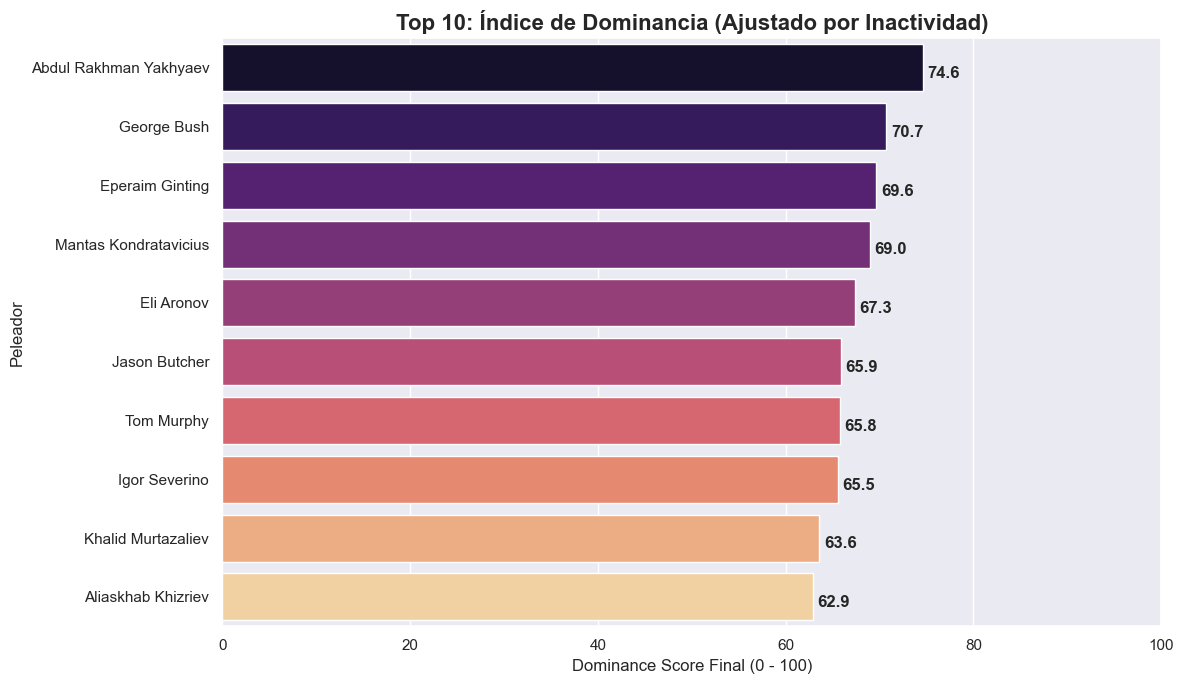

In [36]:
# Configurar el estilo del gráfico
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# Crear el gráfico de barras horizontales con el Score Final Ajustado
barplot = sns.barplot(
    x='Dominance_Final_Score', 
    y='Fighter_Name', 
    data=top_10_p4p_actual, 
    palette='magma' # Cambiamos el color para diferenciarlo del análisis histórico
)

# Añadir las etiquetas de datos
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2. + 0.1, 
             f'{width:.1f}', 
             ha="left", va="center", fontweight='bold')

# Formatear la gráfica
plt.title('Top 10: Índice de Dominancia (Ajustado por Inactividad)', fontsize=16, fontweight='bold')
plt.xlabel('Dominance Score Final (0 - 100)', fontsize=12)
plt.ylabel('Peleador', fontsize=12)
plt.xlim(0, 100) 
plt.tight_layout()

# Mostrar la gráfica
plt.show()